# API structure


# Pricing using the Binomial Tree and BSM Engine


## Example - to show output + show plots for the same

## Convergence Analysis

### Binomial Tree - Steps versus Price (error) 

1. no dividends - European
2. American just plot prices with steps, no error


### Time (because of number of steps) vs Price error
Same as above

### Graphs for both Put and call - assuming no dividends, for everything

1. Delta 
2. Theta
3. Vega
4. Rho 

INCLUDE IMPORTANT = deep ITM European Puts

### Put call parity for European - with and without dividends

### Plots for bounds 

Show bounds + price as spot price S-0 varies 
For boht BSM and binomial (relatively high Number of steps)

For american - assuming no dividends 

### P >= p - no dividends

1. Show as a table for different params

### Option prices + stock prices across 20 days - compare with BSM given the spot price, experiment over different values of sigma

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from quantkit.pricing.core.instruments import Option, OptionType, OptionStyle
from quantkit.pricing.core.market import MarketData
from quantkit.pricing.core.pricer import Pricer

TICKERS  = ["GOOGL", "MSFT", "AAPL"]
T        = 30 / 365   # 30-day option, fixed throughout
r        = 0.05
N_STEPS  = 150        # binomial steps

raw = yf.download(TICKERS, period="40d", auto_adjust=True)["Close"].dropna().tail(20)
print(raw)

[*********************100%***********************]  3 of 3 completed

Ticker            AAPL       GOOGL        MSFT
Date                                          
2026-04-08  258.899994  317.320007  374.329987
2026-04-09  260.489990  318.489990  373.070007
2026-04-10  260.480011  317.239990  370.869995
2026-04-13  259.200012  321.309998  384.369995
2026-04-14  258.829987  332.910004  393.109985
2026-04-15  266.429993  337.119995  411.220001
2026-04-16  263.399994  336.019989  420.260010
2026-04-17  270.230011  341.679993  422.790009
2026-04-20  273.049988  337.420013  418.070007
2026-04-21  266.170013  332.290009  424.160004
2026-04-22  273.170013  339.320007  432.920013
2026-04-23  273.429993  338.890015  415.750000
2026-04-24  271.059998  344.399994  424.619995
2026-04-27  267.609985  350.339996  424.820007
2026-04-28  270.709991  349.779999  429.250000
2026-04-29  270.170013  349.940002  424.459991
2026-04-30  271.350006  384.799988  407.779999
2026-05-01  280.140015  385.690002  414.440002
2026-05-04  276.829987  383.250000  413.619995
2026-05-05  2

In [50]:
def hist_vol(prices: pd.Series) -> float:
    """Annualised vol from daily log-returns (full window)."""
    log_rets = np.log(prices / prices.shift(1)).dropna()
    return float(log_rets.std() * np.sqrt(252))

results = {}   # ticker -> DataFrame

for ticker in TICKERS:
    spots  = raw[ticker]
    sigma  = hist_vol(spots)           # single vol for the whole window
    rows   = []

    for date, S in spots.items():
        K = round(S)                   # ATM strike
        mkt = MarketData(spot=S, rate=r, volatility=sigma)

        eu_put = Pricer.price(
            Option(strike=K, maturity=T, option_type=OptionType.PUT, style=OptionStyle.EUROPEAN),
            mkt, engine="bsm"
        ).price

        am_put = Pricer.price(
            Option(strike=K, maturity=T, option_type=OptionType.PUT, style=OptionStyle.AMERICAN),
            mkt, engine="binomial", steps=N_STEPS
        ).price

        rows.append({"date": date, "spot": S, "eu_put_bsm": eu_put,
                     "am_put_binomial": am_put, "sigma": sigma})

    results[ticker] = pd.DataFrame(rows).set_index("date")

results["GOOGL"].head()

,spot,eu_put_bsm,am_put_binomial,sigma
date,,,,
2026-04-08,317.320007,12.998319,13.072715,0.381216
2026-04-09,318.489990,12.961829,13.039973,0.381216
2026-04-10,317.239990,13.035131,13.107795,0.381216
2026-04-13,321.309998,13.168793,13.243822,0.381216
2026-04-14,332.910004,13.851231,13.926269,0.381216


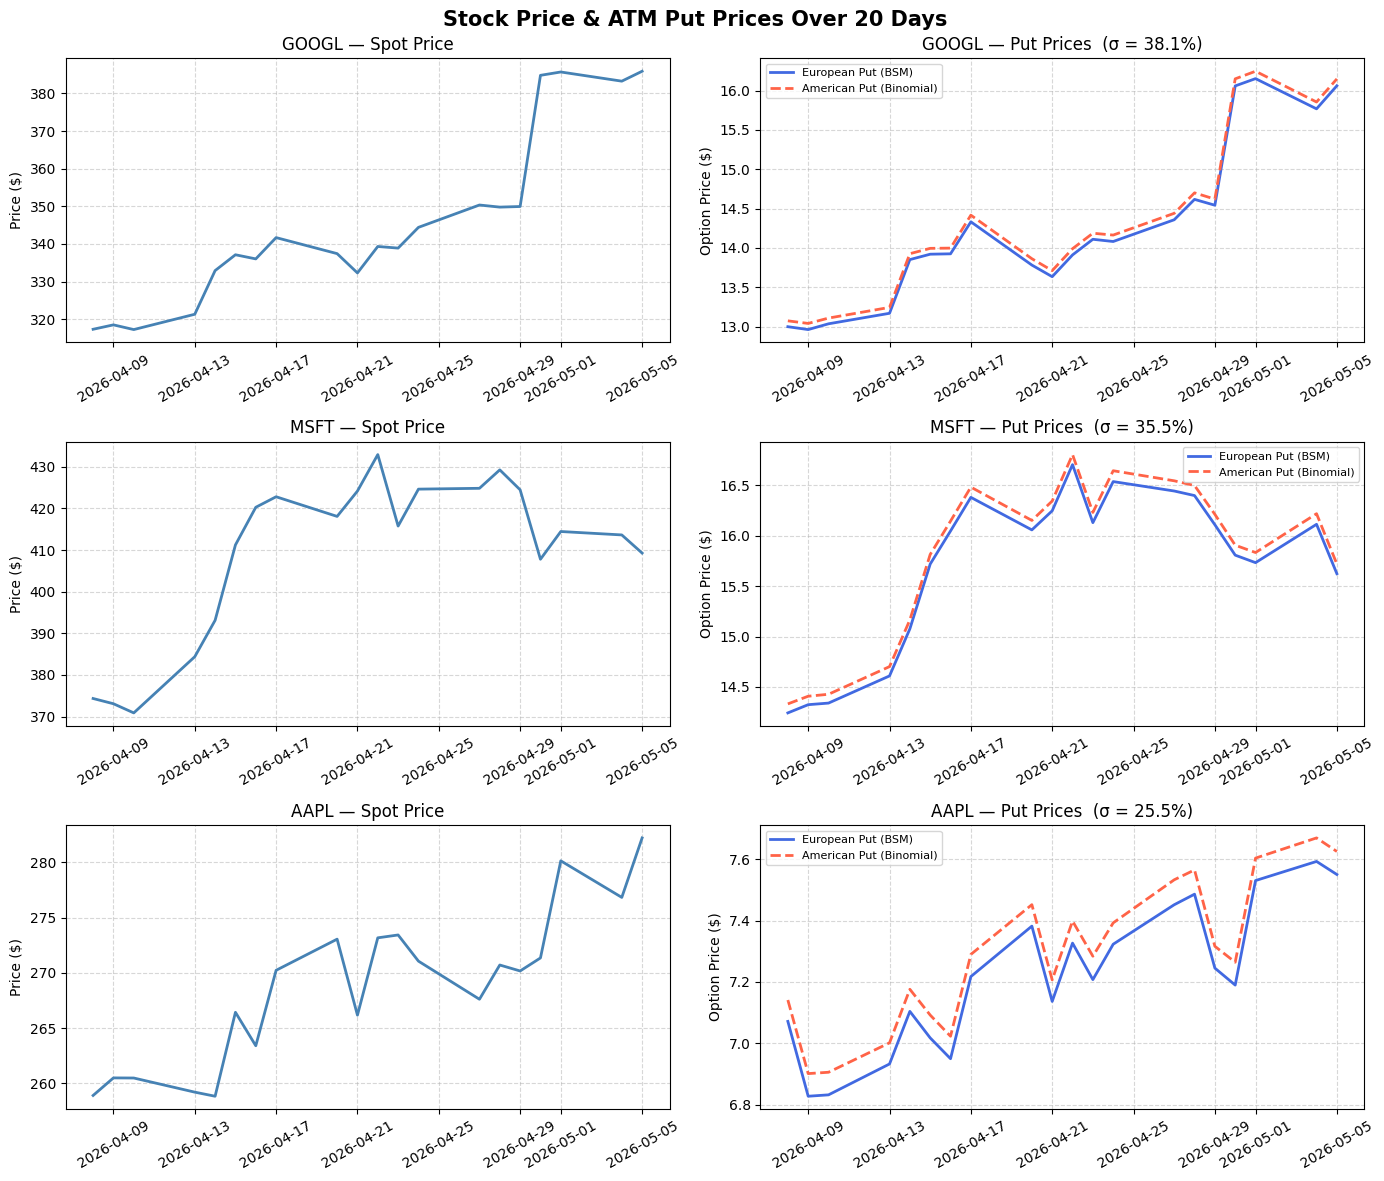

In [51]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle("Stock Price & ATM Put Prices Over 20 Days", fontsize=15, fontweight="bold")

for i, ticker in enumerate(TICKERS):
    df = results[ticker]

    # Left: spot price
    ax_s = axes[i, 0]
    ax_s.plot(df.index, df["spot"], color="steelblue", linewidth=2)
    ax_s.set_title(f"{ticker} — Spot Price")
    ax_s.set_ylabel("Price ($)")
    ax_s.tick_params(axis="x", rotation=30)
    ax_s.grid(True, linestyle="--", alpha=0.5)

    # Right: option prices
    ax_o = axes[i, 1]
    ax_o.plot(df.index, df["eu_put_bsm"],       label="European Put (BSM)",      color="royalblue",  linewidth=2)
    ax_o.plot(df.index, df["am_put_binomial"],   label="American Put (Binomial)", color="tomato",     linewidth=2, linestyle="--")
    sigma_pct = df["sigma"].iloc[0] * 100
    ax_o.set_title(f"{ticker} — Put Prices  (σ = {sigma_pct:.1f}%)")
    ax_o.set_ylabel("Option Price ($)")
    ax_o.tick_params(axis="x", rotation=30)
    ax_o.legend(fontsize=8)
    ax_o.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

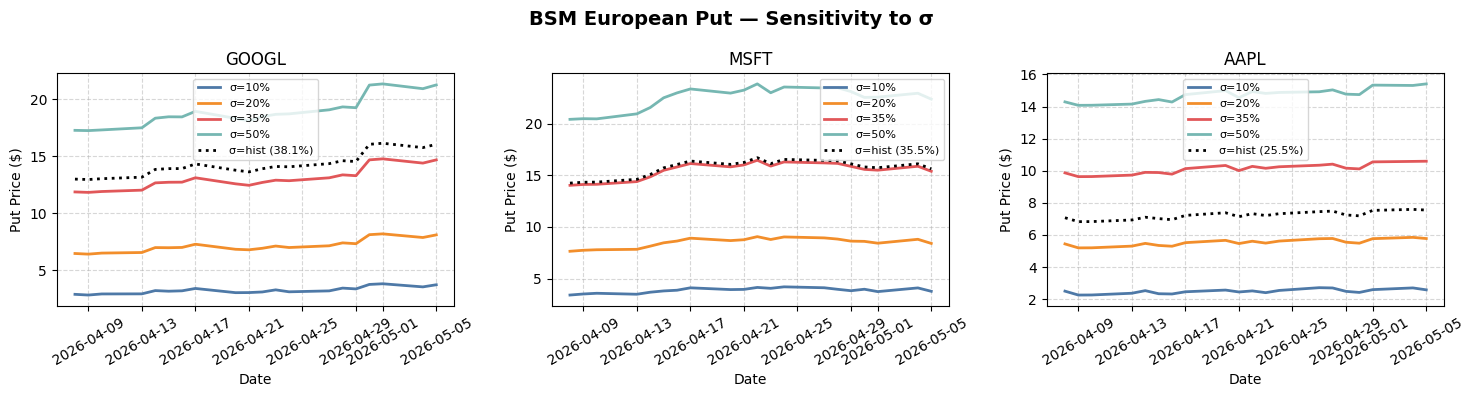

In [52]:
SIGMAS = [0.10, 0.20, 0.35, 0.50]
COLORS = ["#4e79a7", "#f28e2b", "#e15759", "#76b7b2"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
fig.suptitle("BSM European Put — Sensitivity to σ", fontsize=14, fontweight="bold")

for ax, ticker in zip(axes, TICKERS):
    spots = raw[ticker]

    for sigma, color in zip(SIGMAS, COLORS):
        prices = []
        for S in spots:
            K   = round(S)
            mkt = MarketData(spot=S, rate=r, volatility=sigma)
            p   = Pricer.price(
                Option(strike=K, maturity=T, option_type=OptionType.PUT, style=OptionStyle.EUROPEAN),
                mkt, engine="bsm"
            ).price
            prices.append(p)
        ax.plot(spots.index, prices, label=f"σ={int(sigma*100)}%", color=color, linewidth=2)

    # Overlay the realised-vol price
    sigma_hist = hist_vol(spots)
    hist_prices = []
    for S in spots:
        K   = round(S)
        mkt = MarketData(spot=S, rate=r, volatility=sigma_hist)
        p   = Pricer.price(
            Option(strike=K, maturity=T, option_type=OptionType.PUT, style=OptionStyle.EUROPEAN),
            mkt, engine="bsm"
        ).price
        hist_prices.append(p)
    ax.plot(spots.index, hist_prices, label=f"σ=hist ({sigma_hist*100:.1f}%)",
            color="black", linewidth=2, linestyle=":", zorder=5)

    ax.set_title(ticker)
    ax.set_xlabel("Date")
    ax.set_ylabel("Put Price ($)")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()